In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
from fix_grid import fix_grid 
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from useful_calculations import weighted_means

In this script, the mesoscale phenomena were separated into anticyclonic and cyclonic based on the sea surface temperature anomaly. Then, their average FCO2 and FO2 anomalies were separately calculated (maps) as well as a global average (bar plots).

In [2]:
###Load datasets
ds_mom=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_monthly_0181-0190_noice_all.nc')
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc')
corr=xr.open_dataset(pathf+'3x3box_median_corr_monthly_0181-0190_all.nc')
ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_control_noice.nc', chunks='auto')
ds_mask=xr.open_dataset(pathf+'mask_gases_total.nc')

In [3]:
#interpolate 3-dimensional lat/lon grids
ds_mom=fix_grid(ds_mom)
dsa=fix_grid(dsa)
corr=fix_grid(corr)
ds=fix_grid(ds)
ds_mask=fix_grid(ds_mask)

In [4]:
#seperate anticyclonic and cyclonic
pos=dsa.SST.where(dsa.SST>0)
neg=dsa.SST.where(dsa.SST<0)

In [5]:
pos_cc=dsa.SST_1PctTo2X.where(dsa.SST_1PctTo2X>0)
neg_cc=dsa.SST_1PctTo2X.where(dsa.SST_1PctTo2X<0)

In [6]:
#apply masks on gas fluxes
dic_pos=dsa.dic_stf.where(pos>0)
dic_neg=dsa.dic_stf.where(neg<0)
o2_pos=dsa.o2_stf.where(pos>0)
o2_neg=dsa.o2_stf.where(neg<0)

dic_pos_cc=dsa.dic_stf_1PctTo2X.where(pos_cc>0)
dic_neg_cc=dsa.dic_stf_1PctTo2X.where(neg_cc<0)
o2_pos_cc=dsa.o2_stf_1PctTo2X.where(pos_cc>0)
o2_neg_cc=dsa.o2_stf_1PctTo2X.where(neg_cc<0)

In [14]:
dic_pos_zonal

<xarray.DataArray 'dic_stf' (time: 120, yt_ocean: 581)>
array([[        nan,         nan,         nan, ..., -0.06097678,
        -0.08957551, -0.06750894],
       [        nan,         nan,         nan, ..., -0.1597507 ,
        -0.13567121, -0.1485892 ],
       [        nan,         nan,         nan, ..., -0.24031574,
        -0.0960601 , -0.04350968],
       ...,
       [        nan,         nan,         nan, ...,  0.03216645,
        -0.02099646, -0.04190734],
       [        nan,         nan,         nan, ..., -0.12273892,
        -0.1710703 , -0.04946952],
       [        nan,         nan,         nan, ..., -0.47402346,
        -0.39513963, -0.28752622]], dtype=float32)
Coordinates:
  * time      (time) object 0181-01-16 12:00:00 ... 0190-12-16 12:00:00
  * yt_ocean  (yt_ocean) float64 -81.07 -80.73 -80.52 ... 64.68 64.8 64.89
    st_ocean  float64 5.034

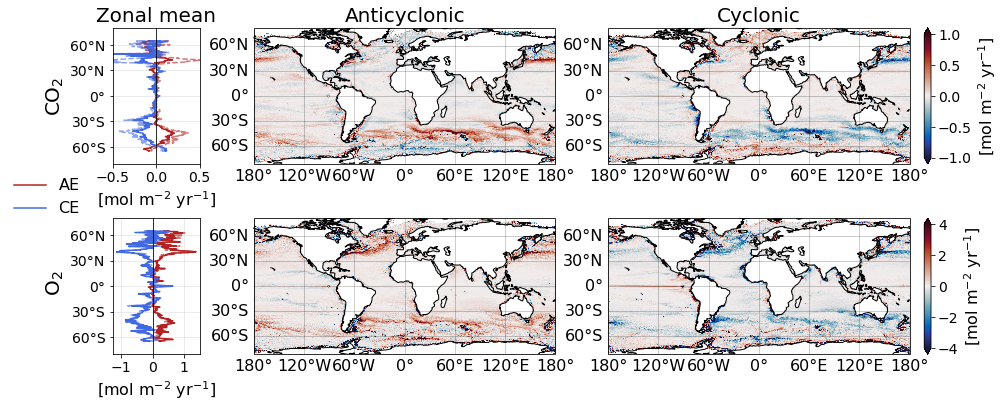

In [20]:

dic_pos_zonal=dic_pos.mean(dim=['xt_ocean', 'time'])
dic_neg_zonal=dic_neg.mean(dim=['xt_ocean', 'time'])
dic_pos_cc_zonal=dic_pos_cc.mean(dim=['xt_ocean', 'time'])
dic_neg_cc_zonal=dic_neg_cc.mean(dim=['xt_ocean', 'time'])


o2_pos_zonal=o2_pos.mean(dim=['xt_ocean', 'time'])
o2_neg_zonal=o2_neg.mean(dim=['xt_ocean', 'time'])
o2_pos_cc_zonal=o2_pos_cc.mean(dim=['xt_ocean', 'time'])
o2_neg_cc_zonal=o2_neg_cc.mean(dim=['xt_ocean', 'time'])

lat_true = ds.geolat_t.where(ds.geolat_t<=90).mean(dim='xt_ocean')
dic_pos_zonal = dic_pos_zonal.assign_coords(yt_ocean=lat_true).where((dic_pos_zonal.yt_ocean<=65) & (dic_pos_zonal.yt_ocean >=-65))
dic_neg_zonal = dic_neg_zonal.assign_coords(yt_ocean=lat_true).where((dic_neg_zonal.yt_ocean<=65) & (dic_neg_zonal.yt_ocean >=-65))
dic_pos_cc_zonal = dic_pos_cc_zonal.assign_coords(yt_ocean=lat_true).where((dic_pos_cc_zonal.yt_ocean<=65) & (dic_pos_cc_zonal.yt_ocean >=-65))
dic_neg_cc_zonal = dic_neg_cc_zonal.assign_coords(yt_ocean=lat_true).where((dic_neg_cc_zonal.yt_ocean<=65) & (dic_neg_cc_zonal.yt_ocean >=-65))
o2_pos_zonal = o2_pos_zonal.assign_coords(yt_ocean=lat_true).where((o2_pos_zonal.yt_ocean<=65) & (o2_pos_zonal.yt_ocean >=-65))
o2_neg_zonal = o2_neg_zonal.assign_coords(yt_ocean=lat_true).where((o2_neg_zonal.yt_ocean<=65) & (o2_neg_zonal.yt_ocean >=-65))
o2_pos_cc_zonal = o2_pos_cc_zonal.assign_coords(yt_ocean=lat_true).where((o2_pos_cc_zonal.yt_ocean<=65) & (o2_pos_cc_zonal.yt_ocean >=-65))
o2_neg_cc_zonal = o2_neg_cc_zonal.assign_coords(yt_ocean=lat_true).where((o2_neg_cc_zonal.yt_ocean<=65) & (o2_neg_cc_zonal.yt_ocean >=-65))


fig = plt.figure(figsize=(15,6), layout='compressed')

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":20,
    "axes.labelsize":16,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 4, 4],   # small left column
    wspace=0.1,
    hspace=0.4
)

# --- Left column (zonal means) ---
ax_zm1 = fig.add_subplot(gs[0, 0])
ax_zm2 = fig.add_subplot(gs[1, 0])

# --- Maps ---
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = True
    gl.ylabels_right= False

    ax.coastlines()

# Row 1 (DIC flux)


im1=dic_pos.mean(dim='time').plot(ax=ax1, cmap=cmo.balance, vmin=-1, vmax=1,
                              x='geolon_t', y='geolat_t', transform=ccrs.PlateCarree(),
                              add_colorbar=False)
dic_neg.mean(dim='time').plot(ax=ax2, cmap=cmo.balance, vmin=-1, vmax=1,
                              x='geolon_t', y='geolat_t', transform=ccrs.PlateCarree(),
                              add_colorbar=False)

# Bottom row: O2 flux
im3=o2_pos.mean(dim='time').plot(ax=ax3, cmap=cmo.balance, vmin=-4, vmax=4,
                             x='geolon_t', y='geolat_t', transform=ccrs.PlateCarree(),
                             add_colorbar=False)
o2_neg.mean(dim='time').plot(ax=ax4, cmap=cmo.balance, vmin=-4, vmax=4,
                             x='geolon_t', y='geolat_t', transform=ccrs.PlateCarree(),
                             add_colorbar=False)

# --------------------------------------------------
# ZONAL MEANS
# --------------------------------------------------

# Plot zonal means

ax_zm1.plot(dic_pos_zonal, dic_pos_zonal.yt_ocean, c='firebrick')
ax_zm1.plot(dic_pos_cc_zonal, dic_pos_cc_zonal.yt_ocean, c='firebrick', linestyle='--', alpha=0.6)
ax_zm1.plot(dic_neg_zonal, dic_neg_zonal.yt_ocean, c='royalblue')
ax_zm1.plot(dic_neg_cc_zonal, dic_neg_cc_zonal.yt_ocean, c='royalblue', linestyle='--', alpha=0.6)

ax_zm2.plot(o2_pos_zonal, o2_pos_zonal.yt_ocean, c='firebrick', label='AE')
ax_zm2.plot(o2_pos_cc_zonal, o2_pos_cc_zonal.yt_ocean, c='firebrick', linestyle='--', alpha=0.6)
ax_zm2.plot(o2_neg_zonal, o2_neg_zonal.yt_ocean, c='royalblue', label='CE')
ax_zm2.plot(o2_neg_cc_zonal, o2_neg_cc_zonal.yt_ocean, c='royalblue', linestyle='--', alpha=0.6)



# Formatting zonal panels
ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1, ax_zm2]:
    ax.set_ylim(-80, 80)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
#ax_zm1.set_xlim(-2.3, 3)
#ax_zm2.set_xlim(-12, 25)

ax_zm1.set_title("Zonal mean")
ax_zm2.set_title(" ")

ax_zm1.set_ylabel("CO$_2$", fontsize=20)
ax_zm2.set_ylabel(" O$_2$", fontsize=20)
#
ax_zm1.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")
ax_zm2.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")
#
# Optional: match x-limits to color range
#ax_zm1.set_xlim(-15, 15)
#ax_zm2.set_xlim(-8, 8)


axs=[ax1, ax2, ax3, ax4]

####ADD Colorbars
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar1.set_label('[mol m$^{-2}$ yr$^{-1}$]')

# --- Colorbar for second row (ax3, ax4) ---
cbar2 = fig.colorbar(
    im3,
    ax=[ax3, ax4],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar2.set_label('[mol m$^{-2}$ yr$^{-1}$]')
###titles

ax1.set_title('Anticyclonic')
ax2.set_title('Cyclonic')
ax3.set_title('')
ax4.set_title('')
ax_zm1.set_xlim((-0.5,0.5))
ax_zm2.legend(loc='upper left', bbox_to_anchor=(-1.3, 1.4), frameon=False);

plt.savefig(pathp+'Polarity_anomalies.png',dpi=300, bbox_inches='tight')


# Provide Numbers

In [7]:
###calculate a weighted mean for the global maps
weightedmeans=weighted_means([dic_pos,dic_neg, o2_pos, o2_neg], ["AC_CO2","C_CO2", "AC_O2", "C_O2"])
weightedmeans=weightedmeans.mean(dim='time')

weightedmeans_cc=weighted_means([dic_pos_cc,dic_neg_cc, o2_pos_cc, o2_neg_cc], ["AC_CO2","C_CO2", "AC_O2", "C_O2"])
weightedmeans_cc=weightedmeans_cc.mean(dim='time')

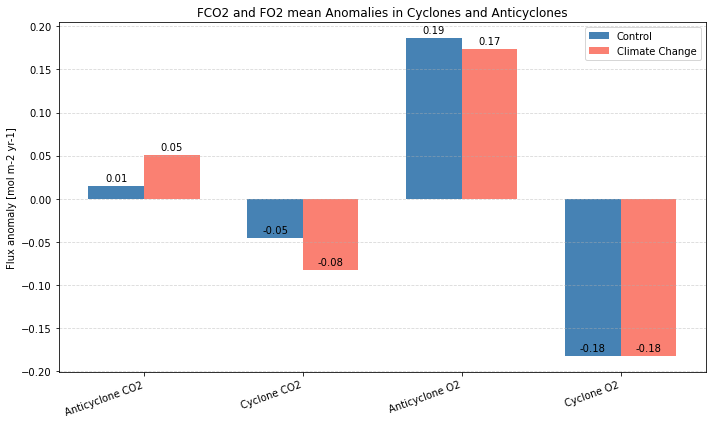

In [8]:
co2_anti_present = weightedmeans['AC_CO2'].values
o2_anti_present =  weightedmeans['AC_O2'].values
co2_cyc_present =  weightedmeans['C_CO2'].values
o2_cyc_present =   weightedmeans['C_O2'].values

co2_anti_cc = weightedmeans_cc['AC_CO2'].values
o2_anti_cc =  weightedmeans_cc['AC_O2'].values
co2_cyc_cc =  weightedmeans_cc['C_CO2'].values
o2_cyc_cc =  weightedmeans_cc['C_O2'].values
# Arrange data
labels = ['Anticyclone CO2', 'Cyclone CO2','Anticyclone O2',  'Cyclone O2']
present = [co2_anti_present,  co2_cyc_present,o2_anti_present, o2_cyc_present]
climate_change = [co2_anti_cc,  co2_cyc_cc, o2_anti_cc,o2_cyc_cc]

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, present, width, label='Control', color='steelblue')
rects2 = ax.bar(x + width/2, climate_change, width, label='Climate Change', color='salmon')

# Add labels, grid, etc
ax.set_ylabel('Flux anomaly [mol m-2 yr-1]')
ax.set_title('FCO2 and FO2 mean Anomalies in Cyclones and Anticyclones')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(pathp+'eddies_separated_gases_glomean.png', dpi=300, bbox_inches='tight');


In [ ]:
#eddies_separated_gases_glomean.png